# Experimento 3 - Fine-tuning completo (lr0=1e-4)

Projeto: **Detecção de Faces para Anonimização de Imagens** (conformidade com a LGPD) - disciplina de Introdução à Ciência de Dados e Aprendizado de Máquina (IFSC).

Neste experimento, **todas as camadas** do YOLO11n são ajustadas no subset do WIDER Face, com **learning rate inicial baixa** (`lr0=1e-4`). A taxa baixa preserva o conhecimento pré-treinado: passos grandes de gradiente no início do treino destruiriam os pesos vindos do COCO antes de o modelo se adaptar à nova tarefa (o chamado *esquecimento catastrófico*).

Hipótese a testar: ajustar também o backbone (e não só as camadas finais, como no experimento 2) permite especializar as características visuais em rostos - potencialmente melhor mAP, ao custo de mais tempo de treino e maior risco de overfitting.

> **Colab:** selecione GPU (T4) em *Ambiente de execução → Alterar o tipo de ambiente de execução*. O treino de 20 épocas leva em torno de 40–70 minutos (mais lento que o experimento 2, pois há gradiente em toda a rede).

## 1. Instalação das dependências

O Colab já traz OpenCV, Matplotlib e Pandas pré-instalados; instalamos apenas a biblioteca `ultralytics` (YOLO11) e confirmamos a versão e a disponibilidade de GPU. A checagem é feita diretamente com `torch.cuda.is_available()` - o utilitário `ultralytics.checks()` dispara subprocessos de inspeção do ambiente que podem travar em algumas máquinas.

In [12]:
%pip install -q "ultralytics>=8.3.0"

import torch
import ultralytics

print('ultralytics', ultralytics.__version__)
print('GPU disponivel:', torch.cuda.is_available())

Note: you may need to restart the kernel to use updated packages.
ultralytics 8.4.65
GPU disponivel: True


## 2. Parâmetros

- Os parâmetros do dataset devem ser **idênticos aos dos notebooks 01 e 02**.
- `EPOCHS = 20`: mesmo orçamento de treino do experimento 2, para comparação justa entre as estratégias.
- `LR0 = 1e-4`: learning rate inicial baixa para o ajuste fino.
- `BATCH = 8` e `WORKERS = 2` limitam o uso de memória durante o treino - a explicação está na seção 4.

**Detalhe importante:** com o padrão `optimizer='auto'`, a Ultralytics **ignora o `lr0` informado** e escolhe a taxa de aprendizado sozinha. Para que o experimento realmente use `lr0=1e-4`, fixamos `optimizer='AdamW'` explicitamente.

In [13]:
import sys
from pathlib import Path

EM_COLAB = 'google.colab' in sys.modules

REPO_URL = 'https://github.com/ifsc-sj-projetos-ia/corrige-aqui'

if EM_COLAB:
    BASE_DIR = Path('/content/projeto-faces')
elif Path.cwd().name == 'notebooks':
    BASE_DIR = Path.cwd().parent
else:
    BASE_DIR = Path.cwd()

NOME_EXPERIMENTO = 'exp3_fine_tuning'
TRAIN_SIZE = 1500
VAL_FRACTION = 0.2
TEST_SIZE = 300
SEED = 42
IMGSZ = 640
EPOCHS = 20
LR0 = 0.0001
OTIMIZADOR = 'AdamW'
BATCH = 8
WORKERS = 2
CONF_VISUALIZACAO = 0.25

## 3. Obtenção e preparação do dataset

Mesmo procedimento dos notebooks anteriores: clone do repositório e execução de `src/prepare_dataset.py`. Com a mesma `SEED`, o subset e os splits são **exatamente os mesmos** dos outros experimentos.

In [14]:
if EM_COLAB and not BASE_DIR.exists():
    !git clone "{REPO_URL}" "{BASE_DIR}"

DATA_DIR = BASE_DIR / 'data'
SUBSET_DIR = DATA_DIR / 'wider_subset'
DATASET_YAML = SUBSET_DIR / 'dataset.yaml'
SCRIPT_PREPARO = BASE_DIR / 'src' / 'prepare_dataset.py'

if not DATASET_YAML.exists():
    !"{sys.executable}" "{SCRIPT_PREPARO}" --data-dir "{DATA_DIR}" --train-size {TRAIN_SIZE} --val-fraction {VAL_FRACTION} --test-size {TEST_SIZE} --seed {SEED}

## 4. Treinamento

Diferenças em relação ao experimento 2:

- **Sem `freeze`**: todos os módulos da rede recebem gradiente e são ajustados.
- **`lr0=1e-4` com AdamW**: ajustes suaves em toda a rede, preservando o conhecimento pré-treinado.

O restante é igual: a cabeça é adaptada automaticamente para 1 classe, a validação seleciona o `best.pt` a cada época e o *data augmentation* padrão da Ultralytics é aplicado. `batch=8` e `workers=2` controlam o uso de memória - a memória do alinhador de alvos cresce com `batch × nº máximo de faces por imagem × nº de anchors`, e cenas de multidão do WIDER Face estouram o batch padrão (16); pelo mesmo motivo o `prepare_dataset.py` exclui imagens com mais de 80 faces (`--max-faces`). Artefatos em `models/exp3_fine_tuning/`.

In [5]:
from ultralytics import YOLO

modelo = YOLO('yolo11n.pt')
resultado_treino = modelo.train(
    data=str(DATASET_YAML),
    epochs=EPOCHS,
    lr0=LR0,
    optimizer=OTIMIZADOR,
    imgsz=IMGSZ,
    batch=BATCH,
    workers=WORKERS,
    seed=SEED,
    project=str(BASE_DIR / 'models'),
    name=NOME_EXPERIMENTO,
    exist_ok=True,
)

Ultralytics 8.4.65  Python-3.14.3 torch-2.12.0+cu132 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Davi\corrige-aqui\data\wider_subset\dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp3_fine_tuning, nbs=64, nms=False, opset=None, optimize=Fal

## 5. Curvas de treinamento

Compare com as curvas do experimento 2: treinar todas as camadas dá mais capacidade de ajuste ao modelo. Observe se a perda de validação acompanha a de treino ou se diverge dela (sinal de overfitting) - essa comparação é um dos pontos pedidos na proposta da disciplina.

As figuras ficam em `models/` (pasta não versionada) - copie para `docs/` as que for usar no relatório.

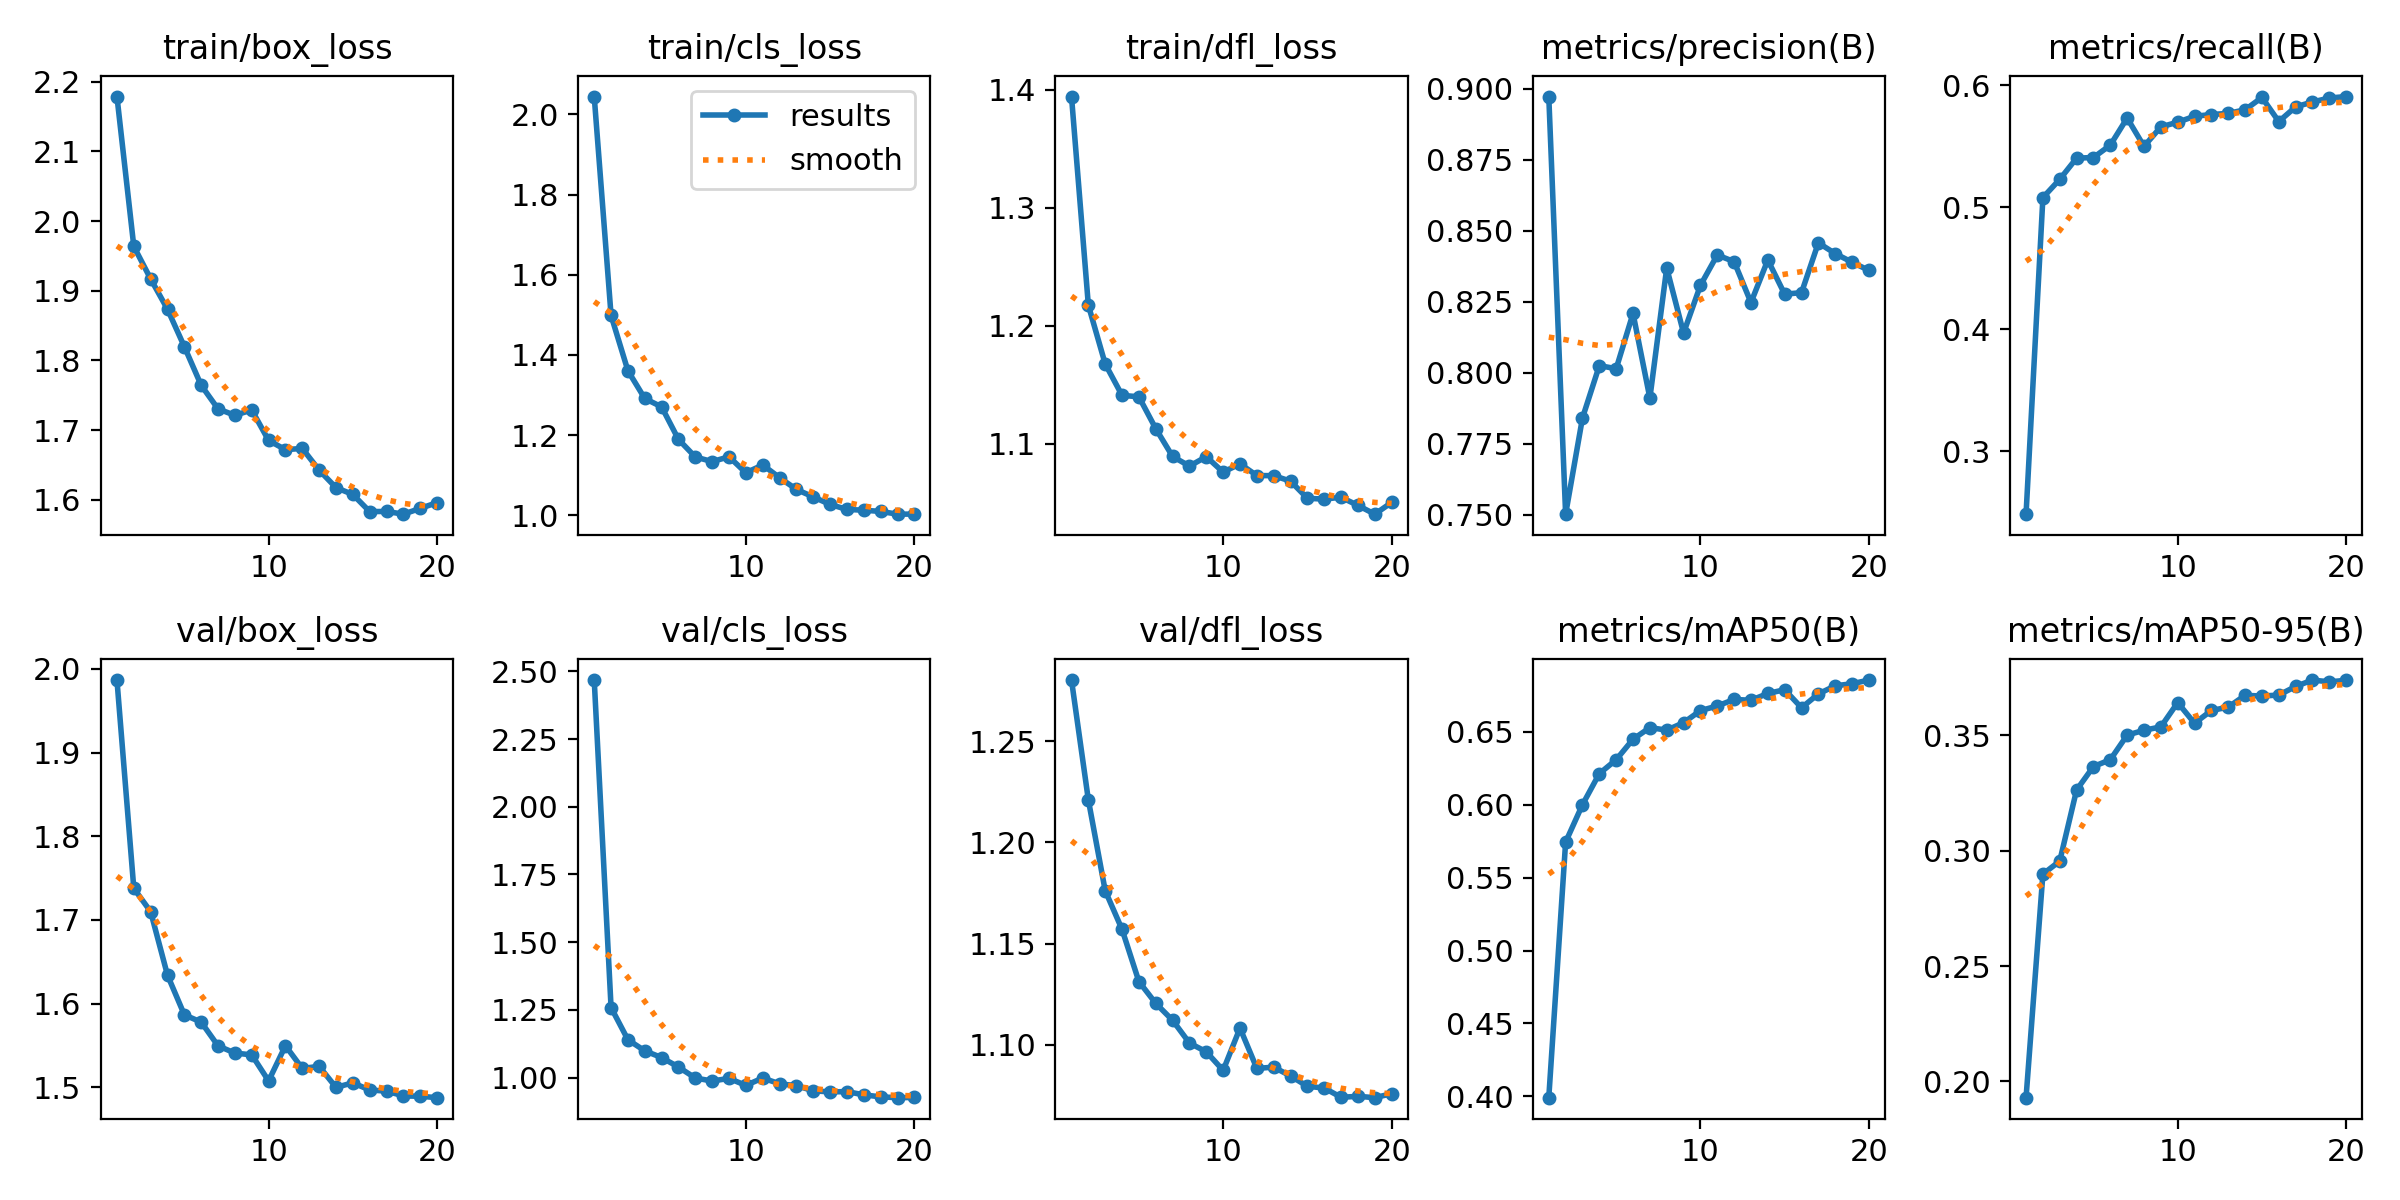

In [6]:
from IPython.display import Image as ExibirImagem

DIR_TREINO = BASE_DIR / 'models' / NOME_EXPERIMENTO
ExibirImagem(filename=str(DIR_TREINO / 'results.png'))

## 6. Avaliação final no conjunto de teste

Como nos demais experimentos: carregamos o `best.pt` (selecionado pela validação) e avaliamos no conjunto de **teste**, nunca visto pelo modelo.

In [18]:
CAMINHO_MELHOR = DIR_TREINO / 'weights' / 'best.pt'
melhor_modelo = YOLO(str(CAMINHO_MELHOR))

resultados_teste = melhor_modelo.val(
    data=str(DATASET_YAML),
    split='test',
    imgsz=IMGSZ,
    plots=True,
    project=str(BASE_DIR / 'models'),
    name=f'val_{NOME_EXPERIMENTO}',
    exist_ok=True,
)

Ultralytics 8.4.65  Python-3.14.3 torch-2.12.0+cu132 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 627.4355.8 MB/s, size: 104.7 KB)
val: Scanning C:\Users\Davi\corrige-aqui\data\wider_subset\test\labels.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 520.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.2it/s 3.7s0.1s
                   all        300       1993      0.845       0.59      0.682      0.376
Speed: 2.1ms preprocess, 3.5ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to C:\Users\Davi\corrige-aqui\models\val_exp3_fine_tuning


## 7. Registro das métricas

Com os CSVs dos experimentos 1 e 2 commitados no repositório, a tabela exibida abaixo é a **tabela comparativa completa** dos três experimentos - a tabela principal da seção de resultados do relatório.

In [8]:
import pandas as pd
from datetime import datetime

CSV_METRICAS = BASE_DIR / 'results' / 'metrics.csv'

metricas = {
    'mAP50': round(float(resultados_teste.box.map50), 4),
    'mAP50_95': round(float(resultados_teste.box.map), 4),
    'precision': round(float(resultados_teste.box.mp), 4),
    'recall': round(float(resultados_teste.box.mr), 4),
    'epochs': EPOCHS,
}

def salvar_metricas(nome_experimento, metricas, caminho_csv):
    linha = {'experimento': nome_experimento, **metricas, 'data_hora': datetime.now().isoformat(timespec='seconds')}
    caminho_csv.parent.mkdir(parents=True, exist_ok=True)
    if caminho_csv.exists():
        tabela = pd.read_csv(caminho_csv)
        tabela = tabela[tabela['experimento'] != nome_experimento]
        tabela = pd.concat([tabela, pd.DataFrame([linha])], ignore_index=True)
    else:
        tabela = pd.DataFrame([linha])
    tabela.to_csv(caminho_csv, index=False)
    return tabela

salvar_metricas(NOME_EXPERIMENTO, metricas, CSV_METRICAS)

,experimento,mAP50,mAP50_95,precision,recall,epochs,data_hora
0,exp1_baseline_pretreinado,0.0009,0.0001,0.0054,0.0522,0,2026-06-11T10:51:54
1,exp2_feature_extraction,0.7101,0.3987,0.8426,0.6312,20,2026-06-11T11:01:28
2,exp3_fine_tuning,0.6816,0.3759,0.8455,0.5896,20,2026-06-11T11:11:07


## 8. Análise qualitativa

Compare as detecções com as do experimento 2 nas mesmas imagens: o fine-tuning completo recupera rostos que o feature extraction perdia (em especial rostos pequenos ou parcialmente ocluídos)?

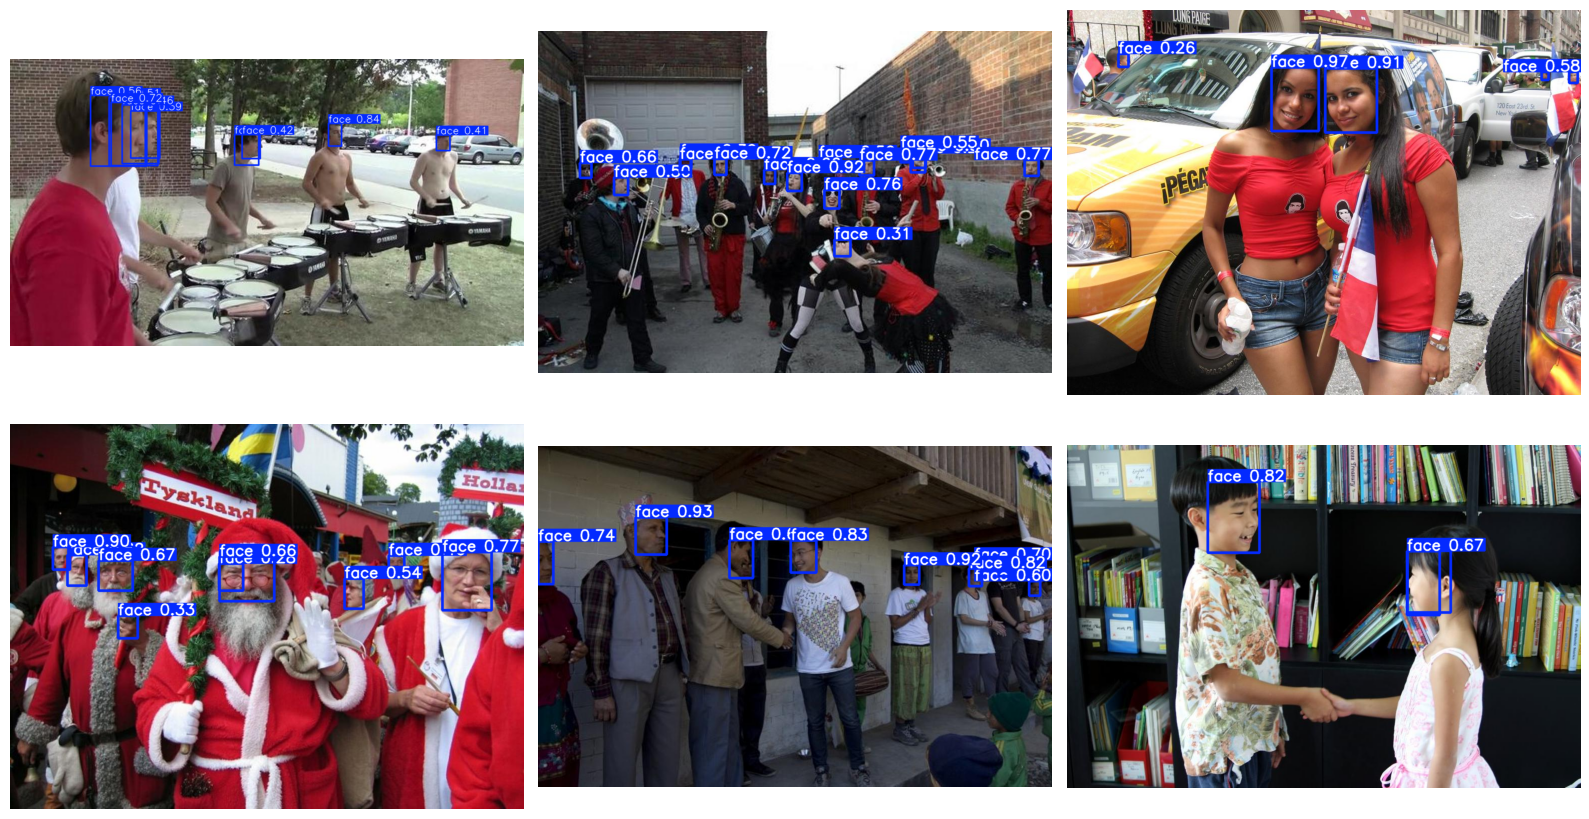

In [16]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt

imagens_teste = sorted((SUBSET_DIR / 'test' / 'images').glob('*.jpg'))[:6]
predicoes = melhor_modelo.predict([str(p) for p in imagens_teste], conf=CONF_VISUALIZACAO, verbose=False)

figura, eixos = plt.subplots(2, 3, figsize=(16, 9))
for eixo, predicao in zip(eixos.flat, predicoes):
    eixo.imshow(cv2.cvtColor(predicao.plot(), cv2.COLOR_BGR2RGB))
    eixo.axis('off')
figura.tight_layout()
plt.show()

## 9. Demonstração: anonimização de rostos

A aplicação-fim do projeto: detectar rostos e **borrá-los** antes do armazenamento, atendendo à LGPD no cenário de plataformas cívicas que recebem fotos de cidadãos. Cada região detectada recebe um desfoque gaussiano com kernel proporcional ao tamanho do rosto, tornando-o irreconhecível sem inutilizar o restante da imagem (que é o que interessa à plataforma).

> O sistema apenas **localiza** rostos: não extrai identidade, não compara rostos entre imagens e não deve ser adaptado para reconhecimento.

As figuras (originais, anonimizadas e o painel comparativo) são **salvas em `models/demo_anonimizacao/`** - pasta fora do controle de versão de propósito: as imagens originais contêm rostos do dataset e não devem ser publicadas no repositório. Copie de lá o que for usar no relatório e na apresentação.

Atenção ao papel do limiar de confiança (`conf`): limiar mais baixo aumenta o recall da anonimização (menos rostos escapam), ao custo de borrar regiões sem rosto. Em um sistema real de privacidade, errar borrando demais é mais seguro do que errar deixando um rosto exposto.

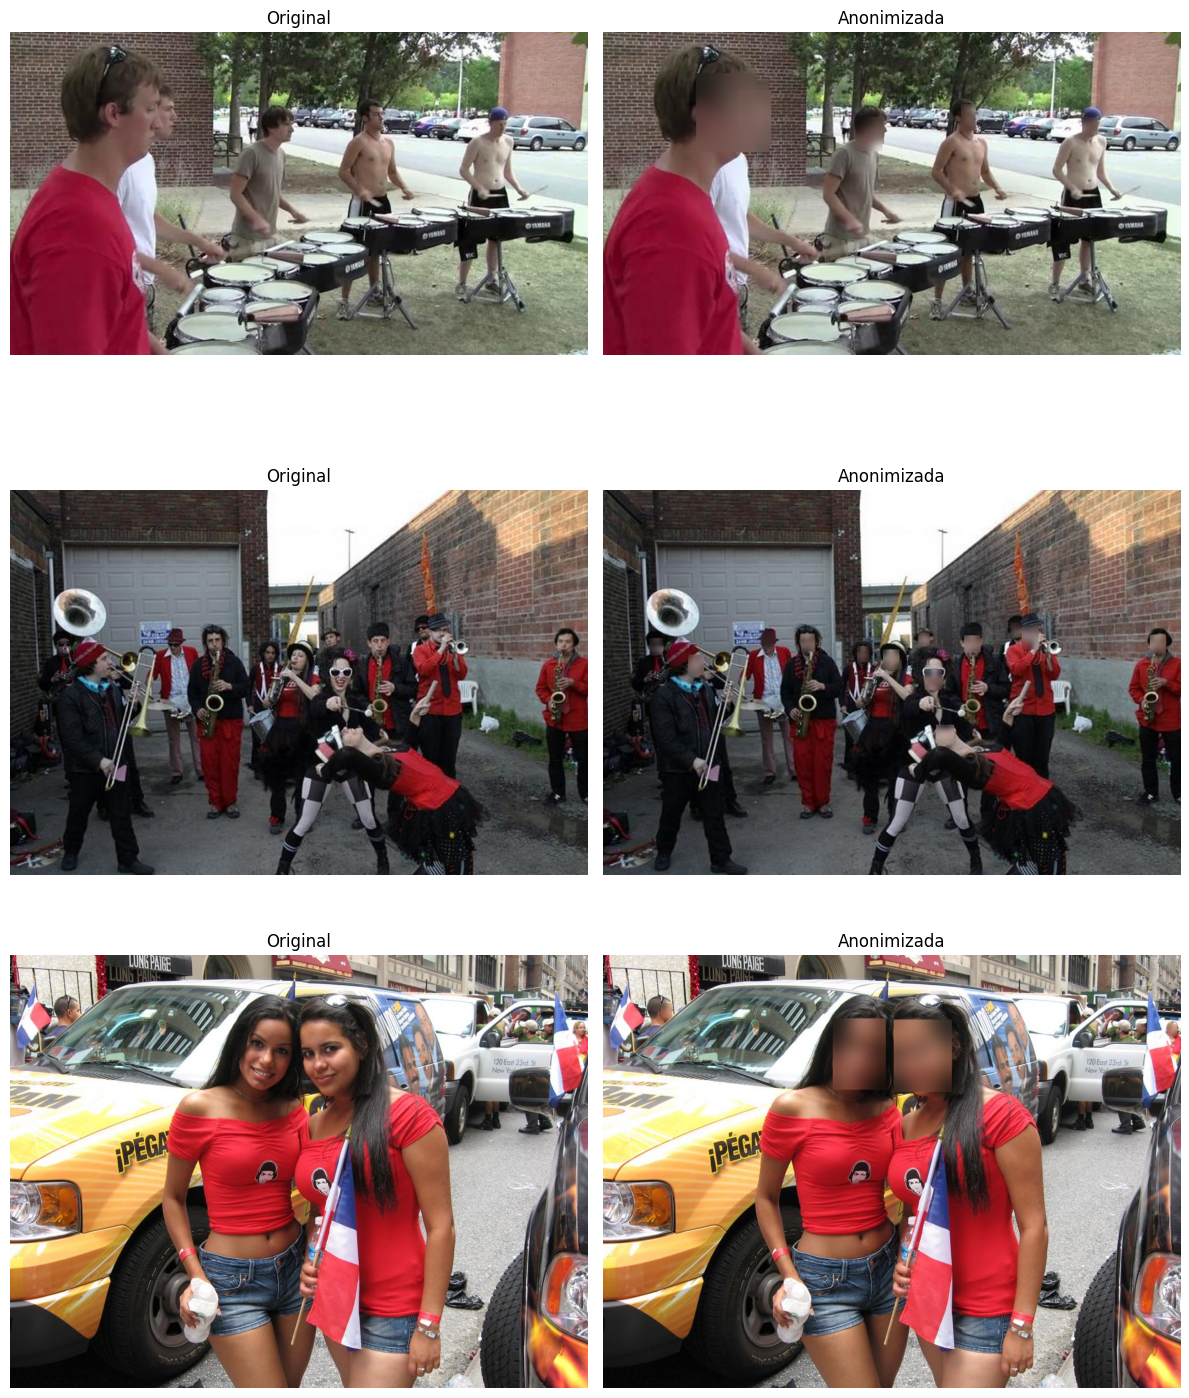

Figuras salvas em c:\Users\Davi\corrige-aqui\models\demo_anonimizacao


In [17]:
DIR_DEMO = BASE_DIR / 'models' / 'demo_anonimizacao'
DIR_DEMO.mkdir(parents=True, exist_ok=True)

def anonimizar_faces(caminho_imagem, modelo_detector, conf):
    imagem = cv2.imread(str(caminho_imagem))
    predicao = modelo_detector.predict(imagem, conf=conf, verbose=False)[0]
    anonimizada = imagem.copy()
    for x1, y1, x2, y2 in predicao.boxes.xyxy.cpu().numpy().astype(int):
        recorte = anonimizada[y1:y2, x1:x2]
        if recorte.shape[0] >= 2 and recorte.shape[1] >= 2:
            k = max(3, min(recorte.shape[0], recorte.shape[1]) // 2 * 2 + 1)
            anonimizada[y1:y2, x1:x2] = cv2.GaussianBlur(recorte, (k, k), 0)
    return imagem, anonimizada

exemplos = imagens_teste[:3]
figura, eixos = plt.subplots(len(exemplos), 2, figsize=(12, 5 * len(exemplos)))
for linha, caminho in zip(eixos, exemplos):
    original, anonimizada = anonimizar_faces(caminho, melhor_modelo, CONF_VISUALIZACAO)
    cv2.imwrite(str(DIR_DEMO / f'{caminho.stem}_original.jpg'), original)
    cv2.imwrite(str(DIR_DEMO / f'{caminho.stem}_anonimizada.jpg'), anonimizada)
    linha[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    linha[0].set_title('Original')
    linha[1].imshow(cv2.cvtColor(anonimizada, cv2.COLOR_BGR2RGB))
    linha[1].set_title('Anonimizada')
    for eixo in linha:
        eixo.axis('off')
figura.tight_layout()
figura.savefig(DIR_DEMO / 'comparacao_anonimizacao.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Figuras salvas em {DIR_DEMO}')

## 10. Download dos resultados (Colab)

Baixe o `metrics.csv` (commitado em `results/`) e o `best.pt` (~5 MB). A pasta `models/` é ignorada pelo git e apenas os pesos do modelo final do projeto (experimento 5) são versionados, em `models/best.pt` - usados pelo script de demonstração `src/anonymize.py`; guarde os deste experimento no Drive ou localmente para reutilizar sem retreinar.

In [11]:
if EM_COLAB:
    from google.colab import files
    files.download(str(CSV_METRICAS))
    files.download(str(CAMINHO_MELHOR))

## Conclusões do experimento

Pontos para discutir no relatório:

1. O fine-tuning completo superou o feature extraction? A diferença justifica o custo extra de treino?
2. Houve sinais de overfitting nas curvas? Como o tamanho reduzido do subset influencia isso?
3. Qual configuração você colocaria em produção na plataforma cívica, considerando que **recall alto é o requisito crítico** (rosto não detectado = dado pessoal exposto)?
4. Limitações a registrar: subset reduzido, possíveis vieses do WIDER Face, rostos pequenos/ocluídos/de perfil, e a dependência do limiar de confiança escolhido para a anonimização.